# Load Gap Data

In [10]:
import json
with open('mnist_multiseed_results.json') as f:
    mnist_gap = json.load(f)

In [11]:

with open('kmnist_multiseed_results.json') as f:
    kmnist_gap = json.load(f)

In [12]:
#for fashionmnist
with open('fashion_gap_20_80.json') as f:
    fashion_saved = json.load(f)
fashion_gap = fashion_saved['results']   

warning onset(sensitivity gap_vs_Sparsity)

In [13]:
def warning_onset(gap, seed):
    pcts = sorted(gap[seed].keys(), key=lambda x: int(x))

    last_below = None   # remembers the last checkpoint where gap was still < 2

    for p in pcts:
        if gap[seed][p] < 2.0:
            last_below = p   # keep updating -- this becomes the LAST one below 2

    if last_below is None:
        return int(pcts[0])   # gap was never below 2, even at the very start

    idx = pcts.index(last_below)

    if idx + 1 < len(pcts):
       return int(pcts[idx + 1])   # the checkpoint right after the last bad one
       
    else:
        return None   # it was below 2 all the way to the end -- never recovered

In [14]:
data_sets ={'MNIST': mnist_gap,'Fashion_MNIST':fashion_gap,'KMNIST':kmnist_gap}
seeds = ['0','42','123']

for name_var,data_set, in data_sets.items():
    for seed in seeds:
        result = warning_onset(data_set,seed)
        print (name_var,seed,result)

MNIST 0 68
MNIST 42 54
MNIST 123 72
Fashion_MNIST 0 41
Fashion_MNIST 42 31
Fashion_MNIST 123 50
KMNIST 0 53
KMNIST 42 46
KMNIST 123 46


# Load Accuracy Data

In [15]:
with open('mnist_full_sweep.json') as f:
    mnist_full = json.load(f)
mnist_acc = mnist_full['uniform_results']

with open('fashion_uniform_acc.json') as f:
    fashion_acc = json.load(f)

with open('kmnist_uniform_acc.json') as f:
    kmnist_acc = json.load(f)

Collapse onset (accuracy vs sparsity), candidate A

In [20]:
def collapse_onset_A(acc, seed):
    # converting test into real number
    pcts_as_text = acc[seed].keys()
    pcts = []
    for points in pcts_as_text:
        pcts.append(int(points))
    pcts.sort()
# making dict so that it also carries the int number

    a = {}
    for p in pcts:
        a[p] = acc[seed][str(p)]
# picking out a calm zone
    calm = []
    for p in pcts:
        if p >=20 and p <= 45:
            calm. append(p)
# find biggest jump between neighbouring calm points
    raw_wobble = 0
    for i in range(1, len(calm)):
        current_val = a[calm[i]]
        previous_val = a[calm[i-1]]
        jump = abs(previous_val-current_val)
        if jump > raw_wobble:
            raw_wobble = jump
    if raw_wobble > 2.0:
        wobble = raw_wobble
    else:
        wobble = 2.0
# walk through every checkpoint looking for real, permamnent drop
    for i in range(1,len(pcts)):
        p = pcts[i]
        pp = pcts[i-1]
        current_val = a[p]
        previous_val = a[pp]
        drop = previous_val - current_val
        if drop > wobble:
            pre_drop_level =  a[pp]
        #checking if accuracy recover at later checkpoints?
            recovers = False
            for q in pcts[i:]:
                if a[q] >= pre_drop_level - wobble:
                    recovers = True
                    break # found one, no need to keep checking
            if recovers == False:
                return p, wobble # never recovered -> this is the real collapse point
    return None , wobble
        


In [21]:

gap_sets = {'MNIST': mnist_gap, 'FashionMNIST': fashion_gap, 'KMNIST': kmnist_gap}
acc_sets = {'MNIST': mnist_acc, 'FashionMNIST': fashion_acc, 'KMNIST': kmnist_acc}
seeds = ['0', '42', '123']

for name in gap_sets:
    for seed in seeds:
        w = warning_onset(gap_sets[name], seed)
        c, wobble = collapse_onset_A(acc_sets[name], seed)
        window = (c - w) if (w is not None and c is not None) else None
        print(f"{name:<14} seed {seed:<4} warning={w}%  collapse={c}%  window={window}  wobble={wobble:.2f}pp")

MNIST          seed 0    warning=68%  collapse=69%  window=1  wobble=2.00pp
MNIST          seed 42   warning=54%  collapse=57%  window=3  wobble=2.00pp
MNIST          seed 123  warning=72%  collapse=71%  window=-1  wobble=2.00pp
FashionMNIST   seed 0    warning=41%  collapse=53%  window=12  wobble=2.13pp
FashionMNIST   seed 42   warning=31%  collapse=57%  window=26  wobble=2.70pp
FashionMNIST   seed 123  warning=50%  collapse=61%  window=11  wobble=2.47pp
KMNIST         seed 0    warning=53%  collapse=58%  window=5  wobble=2.00pp
KMNIST         seed 42   warning=46%  collapse=55%  window=9  wobble=2.00pp
KMNIST         seed 123  warning=46%  collapse=58%  window=12  wobble=2.00pp


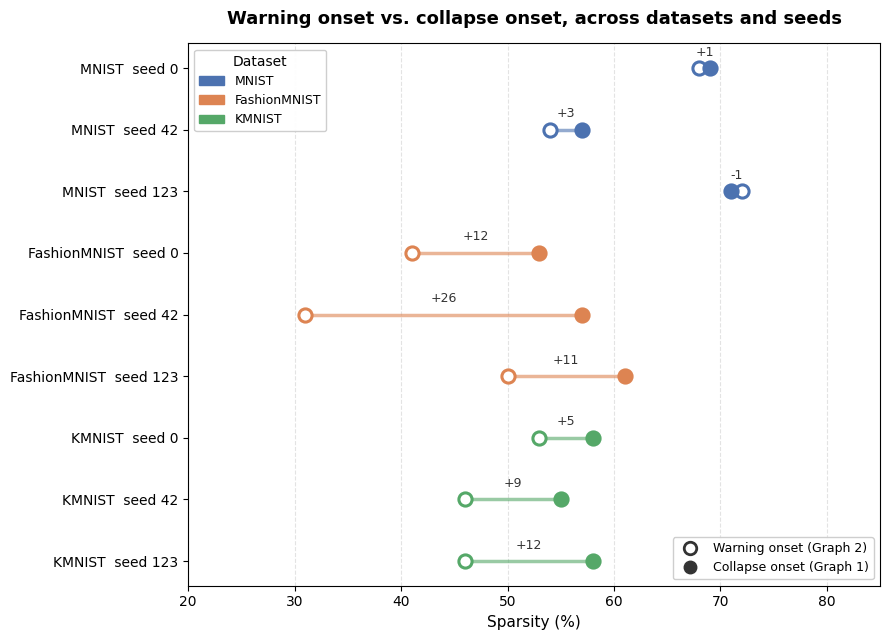

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# your 9 results: (dataset, seed, warning_onset, collapse_onset)
data = [
    ("MNIST", "0",   68, 69),
    ("MNIST", "42",  54, 57),
    ("MNIST", "123", 72, 71),
    ("FashionMNIST", "0",   41, 53),
    ("FashionMNIST", "42",  31, 57),
    ("FashionMNIST", "123", 50, 61),
    ("KMNIST", "0",   53, 58),
    ("KMNIST", "42",  46, 55),
    ("KMNIST", "123", 46, 58),
]

dataset_colors = {
    "MNIST": "#4C72B0",
    "FashionMNIST": "#DD8452",
    "KMNIST": "#55A868",
}

fig, ax = plt.subplots(figsize=(9, 6.5))

labels = []
y_positions = list(range(len(data)))[::-1]  # top to bottom, in the order listed above

for y, (dataset, seed, warn, collapse) in zip(y_positions, data):
    color = dataset_colors[dataset]

    # the connecting line between warning and collapse
    ax.plot([warn, collapse], [y, y], color=color, linewidth=2.5, zorder=1, alpha=0.6)

    # warning point -- open circle
    ax.scatter(warn, y, s=90, facecolors='white', edgecolors=color, linewidth=2.2, zorder=3)

    # collapse point -- filled circle
    ax.scatter(collapse, y, s=90, facecolors=color, edgecolors=color, linewidth=2.2, zorder=3)

    # label the window size above the line
    window = collapse - warn
    mid = (warn + collapse) / 2
    ax.annotate(f"{window:+d}", xy=(mid, y), xytext=(0, 9), textcoords='offset points',
                ha='center', fontsize=9, color='#333333')

    labels.append(f"{dataset}  seed {seed}")

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel("Sparsity (%)", fontsize=11)
ax.set_title("Warning onset vs. collapse onset, across datasets and seeds",
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(20, 85)
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_axisbelow(True)

# two separate legends: one for the dot meaning, one for dataset colors
open_dot = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
                       markeredgecolor='#333333', markeredgewidth=2, markersize=9,
                       label='Warning onset (Graph 2)')
filled_dot = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#333333',
                         markeredgecolor='#333333', markersize=9,
                         label='Collapse onset (Graph 1)')
dataset_patches = [mpatches.Patch(color=c, label=d) for d, c in dataset_colors.items()]

legend1 = ax.legend(handles=[open_dot, filled_dot], loc='lower right', fontsize=9, framealpha=0.95)
ax.add_artist(legend1)
ax.legend(handles=dataset_patches, loc='upper left', fontsize=9, framealpha=0.95, title="Dataset")

plt.tight_layout()
plt.savefig('warning_collapse_dumbbell.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()